<div dir="rtl">

### بررسی تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف

تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف بررسی شود و مشخص شود آیا در بعضی ماه‌ها یا دوره‌های سال افزایش محسوسی در تعداد آگهی‌ها وجود دارد یا نه.

</div>

In [16]:
import numpy as np
import pandas as pd 

In [17]:
import pandas as pd

df = pd.read_parquet("../data/Divar_cleaned.parquet")

In [18]:
print(df["cat2_slug"].value_counts(dropna=False))

cat2_slug
residential-sell        558707
residential-rent        276558
commercial-rent          76565
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64[pyarrow]


In [19]:
# ایجاد یک ستون متفاوت برای جهت دسته بندی به فروش و اجاره

df["listing_type"] = pd.NA

df.loc[
    df["cat2_slug"].isin(["residential-sell", "commercial-sell"]),
    "listing_type"
] = "sale"

df.loc[
    df["cat2_slug"].isin(["residential-rent", "commercial-rent", "temporary-rent"]),
    "listing_type"
] = "rent"

print(df["listing_type"].value_counts(dropna=False)) 


listing_type
sale    597568
rent    383026
<NA>     19403
Name: count, dtype: int64


In [20]:
# بررسی میزان فروش و اجاره در هر ماه و سال و ... 

monthly_counts = (
    df[df["listing_type"].notna()]
    .groupby(["created_year", "created_month", "listing_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(monthly_counts)


listing_type  created_year  created_month   rent   sale
0                     2020              2      0      1
1                     2020             12      1      0
2                     2021              2      0      1
3                     2021              5      0      1
4                     2021              6      0      1
5                     2021             11      0      1
6                     2021             12      1      1
7                     2022              1      0      1
8                     2022              2      1      1
9                     2022              3      1      0
10                    2022              4      3      2
11                    2022              5      4      2
12                    2022              6      3      1
13                    2022              7      3      1
14                    2022              8      3      6
15                    2022              9      5      1
16                    2022             10      2

<div dir="rtl">

### بررسی تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف

برای بررسی روند زمانی آگهی‌ها، ابتدا آگهی‌ها بر اساس `cat2_slug` به دو گروه فروش و اجاره تقسیم شدند. سپس با استفاده از `created_year` و `created_month`، تعداد آگهی‌های هر گروه در ماه‌های مختلف محاسبه و مقایسه شد.

نتایج نشان داد بیشترین حجم آگهی‌های فروش و اجاره مربوط به سال **۲۰۲۴** بوده است.

- بیشترین تعداد آگهی‌های **اجاره** در ماه **۸ (آگوست)** مشاهده شد.
- بیشترین تعداد آگهی‌های **فروش** در ماه **۱۱ (نوامبر)** مشاهده شد.

در نتیجه، اوج فعالیت آگهی‌های اجاره و فروش در بازه‌های زمانی متفاوتی رخ داده است.

پایان شماره سوال شماره 3 آمارتوصیفی.


</div>

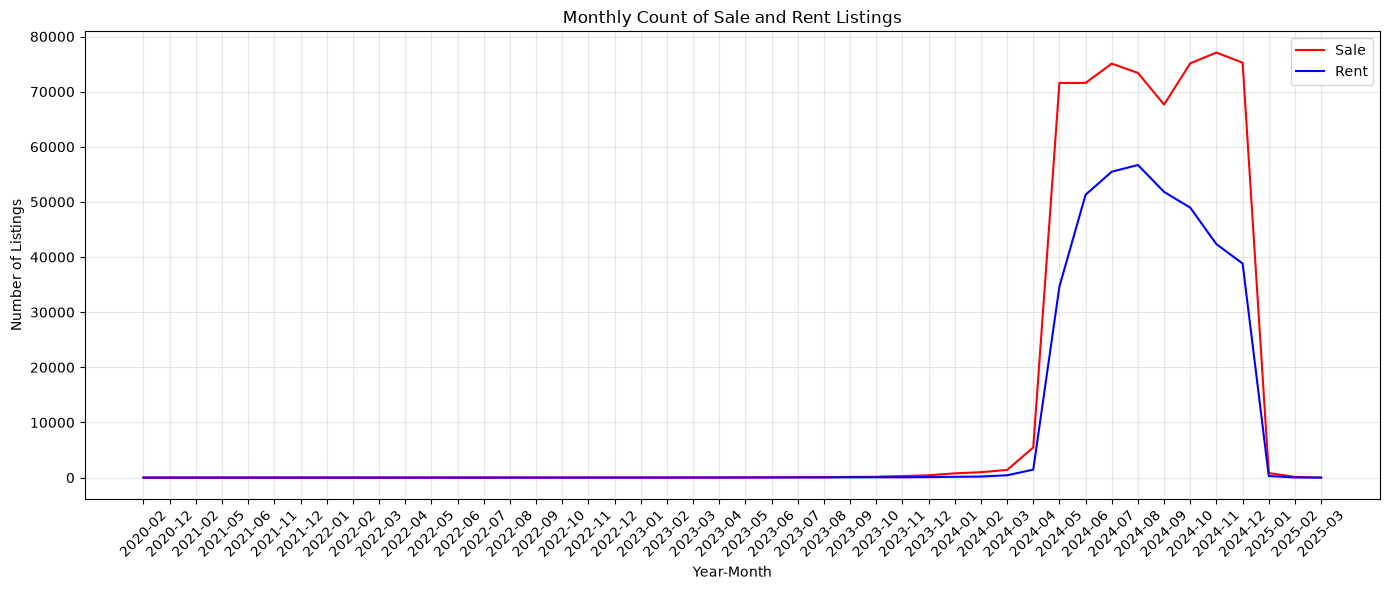

In [21]:
# رسم نمودار خطی برای فروش و اجاره

import matplotlib.pyplot as plt

# گرفتن کپی 
plot_df = monthly_counts.copy()

# Create a proper time label
plot_df["year_month"] = (
    plot_df["created_year"].astype(str)
    + "-"
    + plot_df["created_month"].astype(str).str.zfill(2)
)

# Sort by time
plot_df = plot_df.sort_values(["created_year", "created_month"])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(plot_df["year_month"], plot_df["sale"], color="red", label="Sale")
plt.plot(plot_df["year_month"], plot_df["rent"], color="blue", label="Rent")

plt.title("Monthly Count of Sale and Rent Listings")
plt.xlabel("Year-Month")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

### بررسی توزیع قیمت فروش در دسته‌بندی‌های سطح سه

توزیع قیمت فروش (`price_value`) برای دسته‌بندی‌های مختلف سطح سه (`cat3_slug`) بررسی شود تا تفاوت الگوی قیمت بین انواع مختلف املاک مشخص شود.

در این بخش، قیمت‌های فروش در هر دسته به‌صورت جداگانه بررسی و مقایسه می‌شوند تا میزان پراکندگی، تمرکز قیمت‌ها و تفاوت میان دسته‌های مختلف مشخص شود.

</div>

In [22]:
print("Number of categories:", df["cat3_slug"].nunique(dropna=False))
print()

print(df["cat3_slug"].value_counts(dropna=False))

Number of categories: 16

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121752
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21417
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
Name: count, dtype: int64[pyarrow]


In [23]:
sale_df = df[
    df["cat2_slug"].isin([
        "residential-sell",
        "commercial-sell"
    ])
].copy()

In [24]:
print(sale_df["cat3_slug"].value_counts(dropna=False))

cat3_slug
apartment-sell                        303385
plot-old                              133570
house-villa-sell                      121752
shop-sell                              21855
industry-agriculture-business-sell     11851
office-sell                             5155
Name: count, dtype: int64[pyarrow]


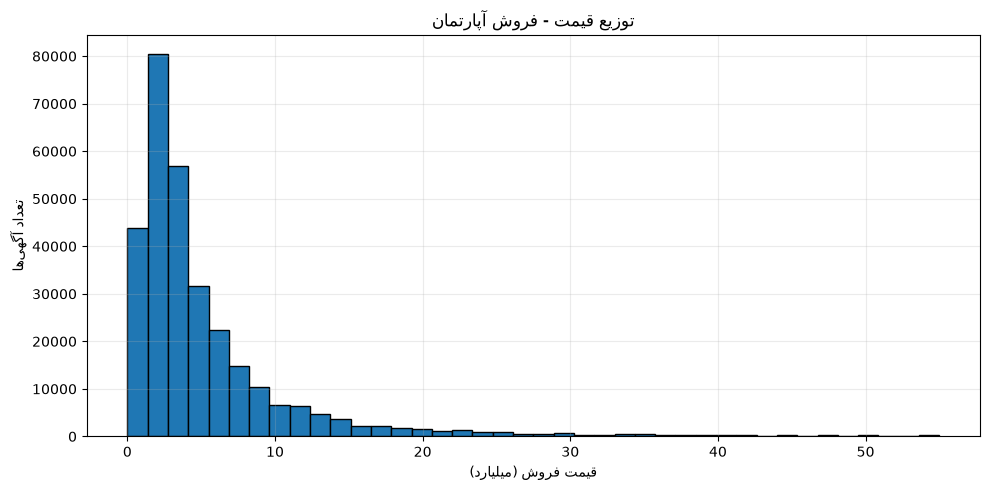

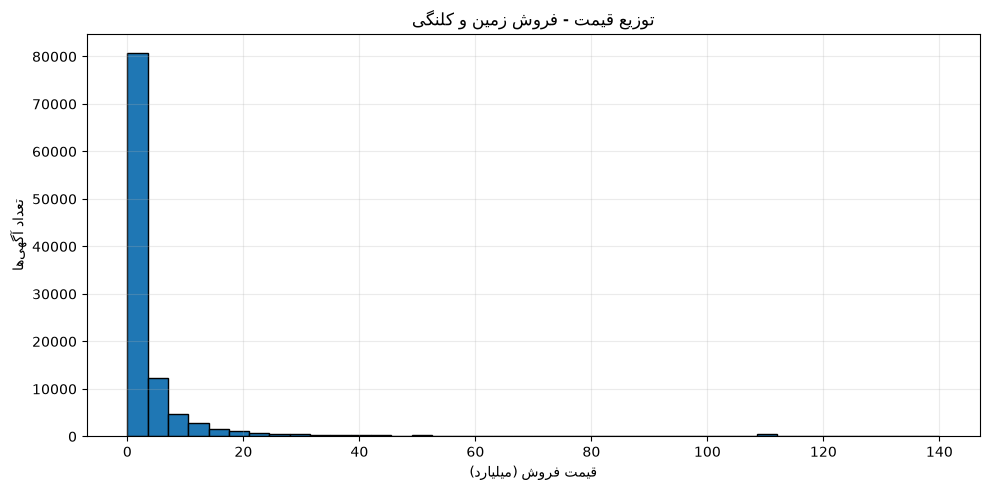

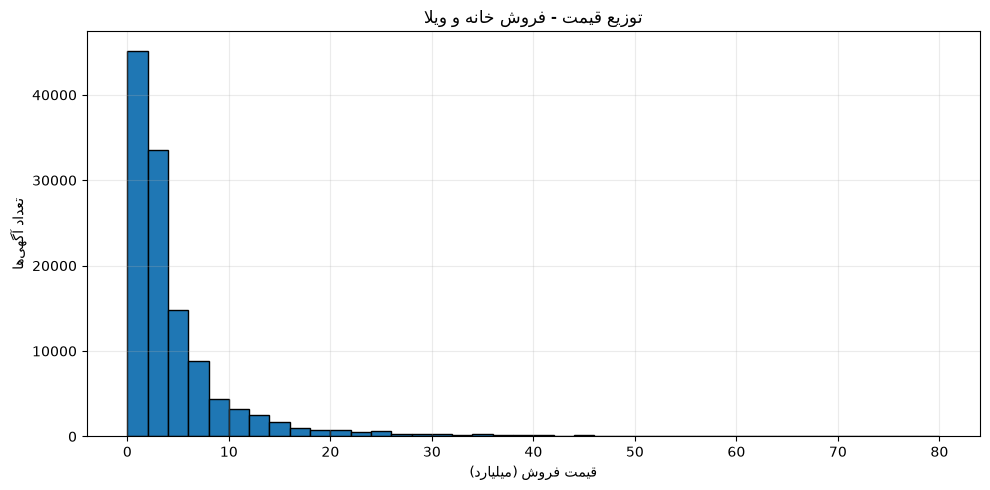

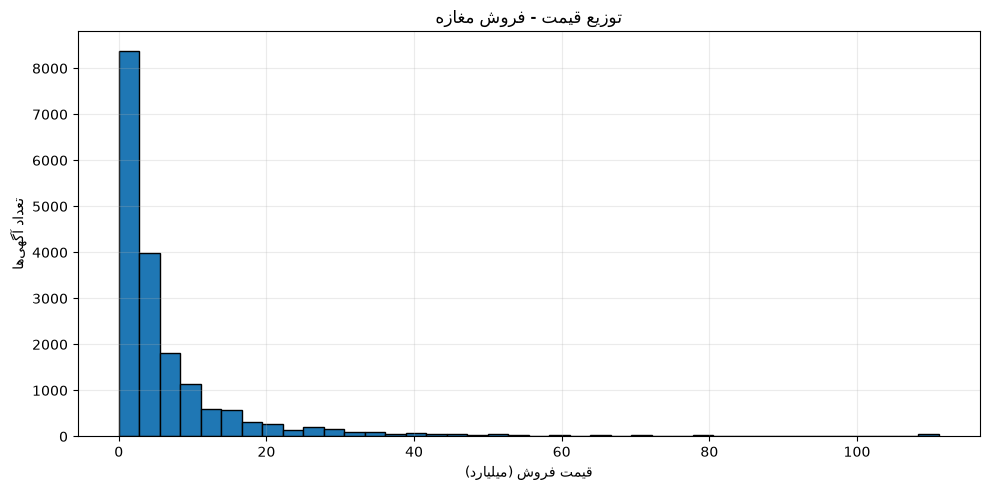

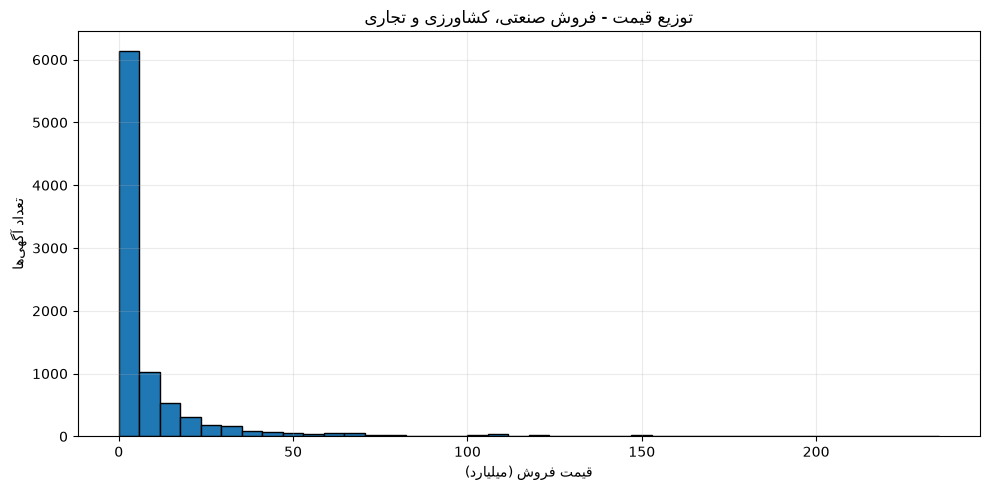

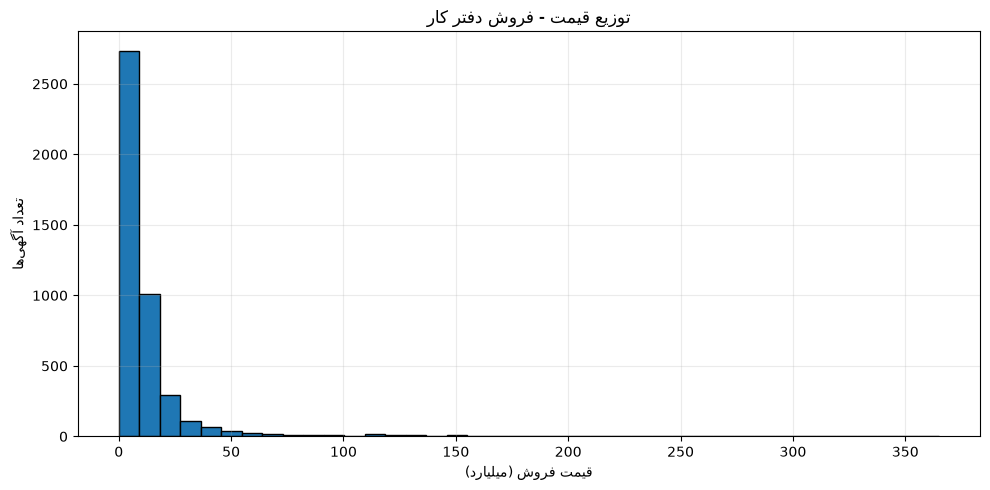

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

category_names = {
    "apartment-sell": "فروش آپارتمان",
    "plot-old": "فروش زمین و کلنگی",
    "house-villa-sell": "فروش خانه و ویلا",
    "shop-sell": "فروش مغازه",
    "industry-agriculture-business-sell": "فروش صنعتی، کشاورزی و تجاری",
    "office-sell": "فروش دفتر کار"
}

for category, title in category_names.items():

    prices = sale_df.loc[
        sale_df["cat3_slug"] == category,
        "price_value"
    ].dropna()

    x_max = prices.quantile(0.99)

    plt.figure(figsize=(10, 5))

    plt.hist(
        prices,
        bins=40,
        range=(0, x_max),
        edgecolor="black"
    )

    plt.gca().xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1e9:.0f}")
    )

    plt.title(f"توزیع قیمت - {title}")
    plt.xlabel("قیمت فروش (میلیارد)")
    plt.ylabel("تعداد آگهی‌ها")

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

<div dir="rtl">

### تحلیل توزیع قیمت فروش در دسته‌بندی‌های سطح سه

برای بررسی توزیع `price_value`، آگهی‌های فروش بر اساس `cat3_slug` به شش گروه اصلی تقسیم شدند:

- فروش آپارتمان
- فروش زمین و کلنگی
- فروش خانه و ویلا
- فروش مغازه
- فروش املاک صنعتی، کشاورزی و تجاری
- فروش دفتر کار

برای هر دسته، توزیع قیمت به‌صورت جداگانه با هیستوگرام بررسی شد. نتایج نشان می‌دهد که توزیع قیمت در تمام دسته‌ها **راست‌چوله (Positive Skewed)** است؛ به این معنی که بخش عمده آگهی‌ها در محدوده‌های قیمتی پایین‌تر و متوسط متمرکز هستند و تعداد کمتری از آگهی‌ها قیمت‌های بسیار بالایی دارند.

در ادامه، برای مقایسه مستقیم دسته‌ها از یک Boxplot مشترک استفاده شد. این نمودار نشان می‌دهد که:

- **دفتر کار** بالاترین میانه قیمت را در میان دسته‌های بررسی‌شده دارد.
- **زمین و کلنگی** پایین‌ترین میانه قیمت را نشان می‌دهد.
- قیمت **آپارتمان** و **خانه و ویلا** نسبت به برخی دسته‌های دیگر تمرکز بیشتری در محدوده‌های میانی دارد.
- **مغازه** و **املاک صنعتی، کشاورزی و تجاری** پراکندگی قیمت نسبتاً بالایی دارند.
- تفاوت قابل‌توجهی در میانه و دامنه تغییرات قیمت بین انواع مختلف ملک مشاهده می‌شود.

در مجموع، نوع ملک تأثیر قابل‌مشاهده‌ای بر توزیع قیمت فروش دارد و نمی‌توان رفتار قیمت تمام دسته‌های ملکی را با یک توزیع واحد توصیف کرد.

> برای خواناتر شدن نمودارهای توزیع، نمایش هیستوگرام‌ها روی محدوده اصلی داده‌ها انجام شده و در Boxplot نیز نقاط پرت نمایش داده نشده‌اند؛ این تنظیمات صرفاً مربوط به نمایش نمودار بوده و داده‌های اصلی تغییر نکرده‌اند.

</div>

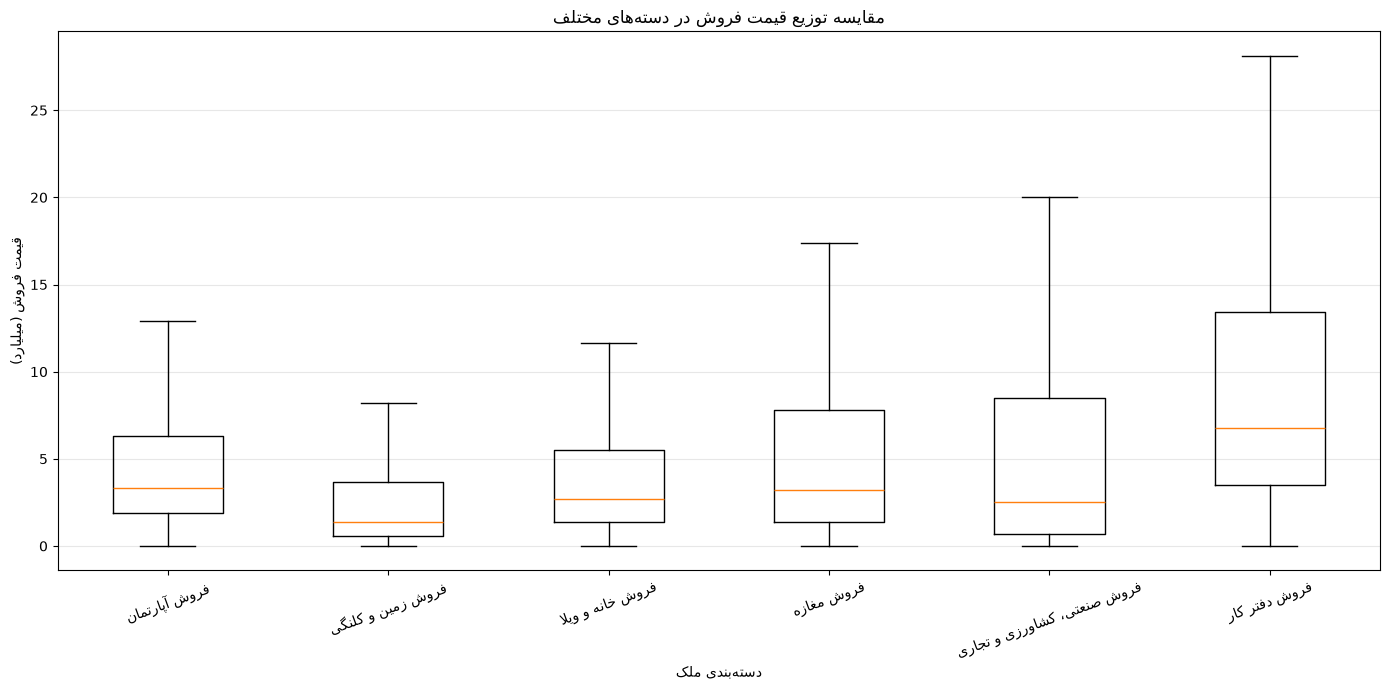

In [26]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

category_names = {
    "apartment-sell": "فروش آپارتمان",
    "plot-old": "فروش زمین و کلنگی",
    "house-villa-sell": "فروش خانه و ویلا",
    "shop-sell": "فروش مغازه",
    "industry-agriculture-business-sell": "فروش صنعتی، کشاورزی و تجاری",
    "office-sell": "فروش دفتر کار"
}

box_data = []
labels = []

for category, title in category_names.items():
    prices = sale_df.loc[
        sale_df["cat3_slug"] == category,
        "price_value"
    ].dropna()

    box_data.append(prices)
    labels.append(title)

plt.figure(figsize=(14, 7))

plt.boxplot(
    box_data,
    tick_labels=labels,
    showfliers=False
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y / 1e9:.0f}")
)

plt.title("مقایسه توزیع قیمت فروش در دسته‌های مختلف")
plt.xlabel("دسته‌بندی ملک")
plt.ylabel("قیمت فروش (میلیارد)")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

### بررسی روند میانگین قیمت اجاره در ماه‌های مختلف

روند میانگین قیمت اجاره بر اساس ماه انتشار آگهی‌ها بررسی و رسم شود.

در این تحلیل باید تغییرات میانگین مبلغ اجاره در طول زمان مشخص شود تا بتوان روند کلی افزایش، کاهش یا نوسان قیمت اجاره را در ماه‌های مختلف مشاهده کرد.

همچنین ماه‌ها باید به شکل خوانا و بر اساس تاریخ شمسی نمایش داده شوند.

</div>

In [27]:
rent_analysis = df[
    df["cat2_slug"].isin([
        "residential-rent",
        "commercial-rent",
        "temporary-rent"
    ])
    &  df["rent_value"].notna()
    & (df["rent_value"] > 0)
    & (df["rent_value"] < df["rent_value"].quantile(0.99))
].copy()

In [28]:
monthly_rent_mean = (
    rent_analysis
    .groupby(["created_year", "created_month"])["rent_value"]
    .mean()
    .reset_index()
)

print(monthly_rent_mean)

    created_year  created_month    rent_value
0           2022              6  3.503333e+07
1           2022              7  4.500000e+07
2           2022              8  7.000000e+07
3           2023              8  6.500000e+07
4           2023              9  2.250000e+07
5           2023             10  4.558333e+07
6           2023             11  2.405714e+07
7           2023             12  3.491818e+07
8           2024              1  2.982404e+07
9           2024              2  2.895076e+07
10          2024              3  3.110274e+07
11          2024              4  2.524382e+07
12          2024              5  1.559455e+07
13          2024              6  1.290126e+07
14          2024              7  1.312168e+07
15          2024              8  1.288869e+07
16          2024              9  1.332383e+07
17          2024             10  1.471550e+07
18          2024             11  1.505913e+07
19          2024             12  1.583720e+07
20          2025              1  3

In [29]:
%pip install jdatetime

Note: you may need to restart the kernel to use updated packages.


<div dir="rtl">

### تحلیل روند میانگین ماهانه قیمت اجاره

برای بررسی روند قیمت اجاره، فقط آگهی‌های اجاره‌ای دارای `rent_value_clean > 0` در نظر گرفته شدند؛ بنابراین آگهی‌های رهن کامل و مقادیر پرت شدید از محاسبه میانگین کنار گذاشته شدند.

بررسی نمودار نشان می‌دهد که در بخش پرتراکم داده‌ها، به‌خصوص طی سال ۲۰۲۴، میانگین اجاره ابتدا کاهش پیدا کرده و در میانه سال به محدوده نسبتاً باثباتی رسیده است. از ماه‌های پایانی سال ۲۰۲۴ دوباره روند افزایشی مشاهده می‌شود.

در سال ۲۰۲۴ میانگین اجاره از حدود **۱۸ میلیون** در ماه پنجم به حدود **۱۴ تا ۱۵ میلیون** در ماه‌های میانی سال کاهش یافته و سپس از ماه دهم به بعد افزایش پیدا کرده و در ماه دوازدهم به حدود **۱۸.۳ میلیون** رسیده است.

داده‌های سال‌های ۲۰۲۲، ۲۰۲۳ و ابتدای ۲۰۲۵ تعداد آگهی بسیار کمتری دارند؛ بنابراین نوسانات مشاهده‌شده در این بازه‌ها نسبت به سال ۲۰۲۴ از اعتبار آماری کمتری برخوردارند.

در مجموع، در بخش اصلی داده‌ها ابتدا یک دوره کاهش و ثبات در میانگین اجاره و سپس یک روند افزایشی در ماه‌های پایانی مشاهده می‌شود.

</div>

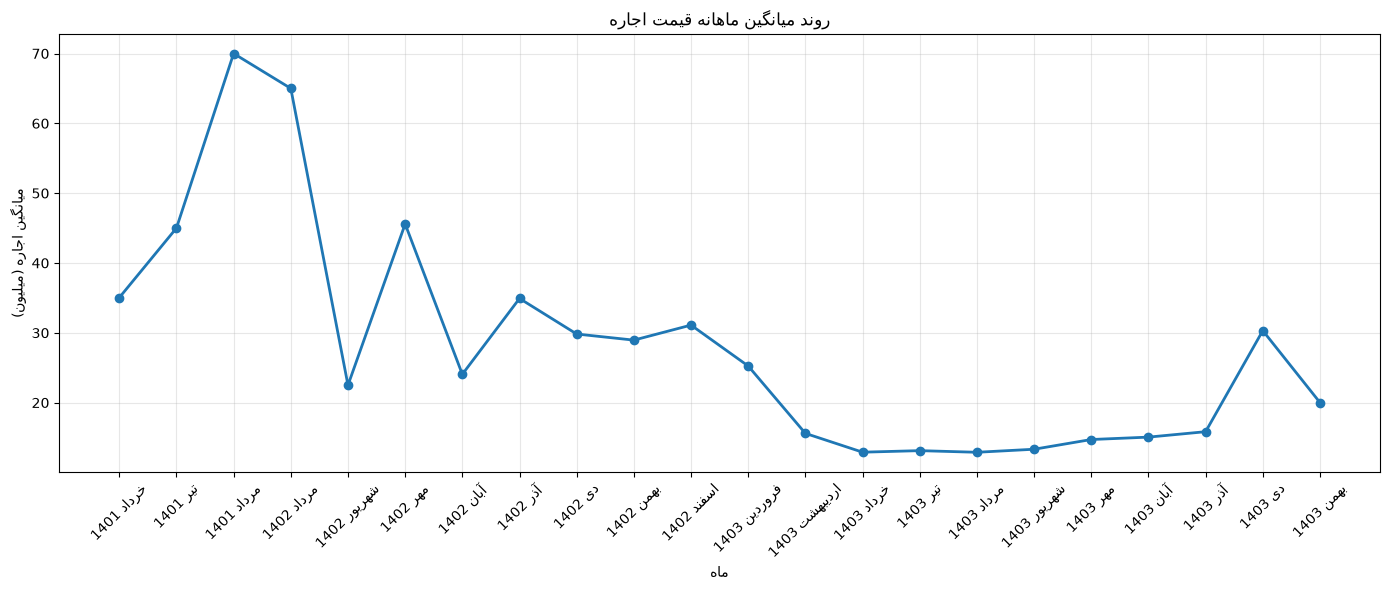

In [30]:
import matplotlib.pyplot as plt
import jdatetime
from matplotlib.ticker import FuncFormatter

persian_months = {
    1: "فروردین",
    2: "اردیبهشت",
    3: "خرداد",
    4: "تیر",
    5: "مرداد",
    6: "شهریور",
    7: "مهر",
    8: "آبان",
    9: "آذر",
    10: "دی",
    11: "بهمن",
    12: "اسفند"
}

plot_rent = monthly_rent_mean.copy()

def to_jalali_label(row):
    jalali_date = jdatetime.date.fromgregorian(
        year=int(row["created_year"]),
        month=int(row["created_month"]),
        day=1
    )

    return f"{persian_months[jalali_date.month]} {jalali_date.year}"

plot_rent["jalali_month"] = plot_rent.apply(
    to_jalali_label,
    axis=1
)

plot_rent = plot_rent.sort_values(
    ["created_year", "created_month"]
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_rent["jalali_month"],
    plot_rent["rent_value"],
    marker="o",
    linewidth=2
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y / 1e6:.0f}")
)

plt.title("روند میانگین ماهانه قیمت اجاره")
plt.xlabel("ماه")
plt.ylabel("میانگین اجاره (میلیون)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()